# Knuth-Morris-Pratt (KMP) String Matching

**Domain:** `data-structures-algorithms`

Think about hitting **Ctrl+F** to search for a word inside a huge document.
Somewhere under the hood, the editor is sliding your search term along the
text, checking "does the text match here?" at every position. Now imagine a
dumb version of that search: at each position, it compares character by
character, and the moment something doesn't match, it throws away
*everything* it just learned and starts completely over at the next
position, one character to the right.

That's wasteful. If you'd already matched `"ABABAB"` against the text
before hitting a mismatch, you *know* things about what comes next in the
text -- you don't need to forget all of that and start blindly comparing
from scratch again. **Knuth-Morris-Pratt (KMP)** is the algorithm that
makes this rigorous: it precomputes, once, exactly how much of a partial
match can be reused after a failure, so the search never re-reads a text
character it doesn't have to.

By the end of this tutorial you'll be able to: explain why the naive
search is slow in the worst case, hand-trace KMP's "failure function" for
a small pattern, prove why the resulting search never has to backtrack
through the text, and run a real, compiled C++ implementation that
measures the comparison-count gap between naive search and KMP on both
typical and adversarial input.

## The idea, intuitively

### The naive approach, and why it can be slow

The **naive (brute-force) search** tries every possible starting position
in the text. At each position, it compares the pattern against the text
character by character; on the first mismatch, it gives up and slides the
pattern one position to the right:

```
text:    A A A A A A A A A A A A A A A
pattern: A A A A A A A A A A A A A A B     <- try at position 0, fails at the very end
          A A A A A A A A A A A A A A B    <- slide by 1, try again, fails at the end again
           A A A A A A A A A A A A A A B   <- and again...
```

Here's the adversarial case that makes this genuinely slow: text is a long
run of `"AAAA...A"` (length $n$) and the pattern is `"AAAA...AAB"` (length
$m$, all `A`s except the last character). At *every* one of the
$n - m + 1$ starting positions, the naive search matches all the way
through $m - 1$ characters before finally failing on the last one. That's
roughly $n \cdot m$ character comparisons -- **$O(nm)$ worst case**. For a
10,000-character text and a 100-character pattern, that's on the order of
a million comparisons to search once.

**The key wasted opportunity:** when the naive search fails after matching
`k` characters, it *already knows* what those `k` text characters are --
it just read them. It throws that knowledge away and starts over. KMP's
whole idea is to not throw it away.

### KMP's key idea

Before searching, KMP looks at the **pattern alone** (not the text at all)
and precomputes a **failure function** (also called the *prefix
function*): for every prefix of the pattern, "if I match this many
characters and then fail, how much of that match can I keep, based on the
pattern's own internal repeated structure?"

Let's hand-trace it for a small pattern: `"ABABAC"` (length 6, indices
0-5). For each prefix `pattern[0..i]`, `fail[i]` is the length of the
longest string that is **both** a proper prefix and a suffix of that
prefix (proper means it can't be the whole string):

| `i` | prefix `pattern[0..i]` | longest proper prefix that's also a suffix | `fail[i]` |
|---|---|---|---|
| 0 | `A` | (none -- single char has no *proper* prefix/suffix) | 0 |
| 1 | `AB` | (none: `A` vs `B` don't match as prefix/suffix) | 0 |
| 2 | `ABA` | `A` (prefix `A` == suffix `A`) | 1 |
| 3 | `ABAB` | `AB` (prefix `AB` == suffix `AB`) | 2 |
| 4 | `ABABA` | `ABA` (prefix `ABA` == suffix `ABA`) | 3 |
| 5 | `ABABAC` | (none: ends in `C`, no prefix ends in `C`) | 0 |

So `fail = [0, 0, 1, 2, 3, 0]`. Here's that exact computation as real,
runnable Python -- small enough to trace by eye, but the literal
algorithm used later in the C++ implementation:

In [1]:
def build_failure_function(pattern):
    """fail[i] = length of the longest proper prefix of pattern[0..i]
    that is also a suffix of pattern[0..i]."""
    m = len(pattern)
    fail = [0] * m
    k = 0  # length of the current matching prefix/suffix
    for i in range(1, m):
        while k > 0 and pattern[i] != pattern[k]:
            k = fail[k - 1]   # reuse: jump to the next-best candidate length
        if pattern[i] == pattern[k]:
            k += 1
        fail[i] = k
    return fail

pattern = "ABABAC"
fail = build_failure_function(pattern)
print("pattern:", " ".join(pattern))
print("index:  ", " ".join(str(i) for i in range(len(pattern))))
print("fail:   ", " ".join(str(f) for f in fail))
assert fail == [0, 0, 1, 2, 3, 0]
print("\nmatches the hand-traced table above")

pattern: A B A B A C
index:   0 1 2 3 4 5
fail:    0 0 1 2 3 0

matches the hand-traced table above


**Takeaway:** the failure function is a one-time, pattern-only
computation. Once you have it, you can search the text and, whenever a
match attempt fails partway through, immediately know how much of the
pattern is still known to match -- no re-reading of text required.

### A small search example: the text pointer never moves backward

Let's search for `"ABABAC"` inside the text `"ABABABABAC"` using the
failure function above, and watch what the *text* index does at each step
(this is the property to watch for -- it's what makes KMP linear, proved
in the next section):

In [2]:
def kmp_search_traced(text, pattern):
    fail = build_failure_function(pattern)
    n, m = len(text), len(pattern)
    k = 0  # number of pattern characters currently matched
    matches = []
    for i in range(n):  # i (the text pointer) only ever increases
        while k > 0 and text[i] != pattern[k]:
            print(f"  i={i} text[i]={text[i]!r} vs pattern[{k}]={pattern[k]!r}: MISMATCH, "
                  f"reuse fail[{k-1}]={fail[k-1]} -> k={fail[k-1]} (i does NOT move)")
            k = fail[k - 1]
        if text[i] == pattern[k]:
            k += 1
        if k == m:
            matches.append(i - m + 1)
            print(f"  i={i}: MATCH ending here, pattern found at text[{i - m + 1}]")
            k = fail[k - 1]
    return matches

text, pattern = "ABABABABAC", "ABABAC"
print(f"text:    {text}")
print(f"pattern: {pattern}\n")
found = kmp_search_traced(text, pattern)
print(f"\nmatches at: {found}")

text:    ABABABABAC
pattern: ABABAC

  i=5 text[i]='B' vs pattern[5]='C': MISMATCH, reuse fail[4]=3 -> k=3 (i does NOT move)
  i=7 text[i]='B' vs pattern[5]='C': MISMATCH, reuse fail[4]=3 -> k=3 (i does NOT move)
  i=9: MATCH ending here, pattern found at text[4]

matches at: [4]


Notice the text index `i` in the loop above only ever counts
**up**. Every time a mismatch happens, KMP falls back to a shorter known
match length (`k = fail[k-1]`) and re-tests the *same* text character
against a shorter prefix of the pattern -- it never steps `i` backward to
re-read text it has already consumed. That single property is what turns
the search into a linear pass over the text, and it's proven formally
below.

## Going deeper: the formal definition

### The failure function, formally

For a pattern $P$ of length $m$, define for every index $i \in \{0, \dots, m-1\}$:

$$
\text{fail}[i] = \max \{\, k : 0 \le k < i+1,\ P[0..k-1] = P[i-k+1..i] \,\}
$$

in words: $\text{fail}[i]$ is the length of the **longest proper prefix**
of $P[0..i]$ that is **also a suffix** of $P[0..i]$ (the "longest proper
prefix which is also a suffix," LPS). "Proper" excludes $k = i+1$ (the
whole substring matching itself trivially); by convention $\text{fail}[i] \ge 0$,
with $0$ meaning no such prefix/suffix exists other than the empty string.

### Why this lets you skip re-comparisons: the correctness argument

Suppose during a search, the pattern is matched against the text and gets
`k` characters in -- i.e. $P[0..k-1] = T[s..s+k-1]$ for some text start
position $s$ -- and then the next comparison, $T[s+k]$ vs $P[k]$, fails.

**Claim:** the next position worth trying is $s' = s + k - \text{fail}[k-1]$,
and at that new position, the first $\text{fail}[k-1]$ characters of the
pattern are *already known* to match the text, with zero new comparisons.

**Why:** Let $j = \text{fail}[k-1]$, the length of the longest proper
prefix of $P[0..k-1]$ that's also a suffix of $P[0..k-1]$. By definition:

$$
P[0..j-1] = P[k-j..k-1]
$$

But we already know $P[0..k-1] = T[s..s+k-1]$ (that's what "matched `k`
characters" means), so in particular the *suffix* of that matched region,
$P[k-j..k-1]$, equals $T[s+k-j..s+k-1]$. Combining the two equalities:

$$
P[0..j-1] = P[k-j..k-1] = T[s+k-j..s+k-1] = T[s'..s'+j-1]
$$

where $s' = s + k - j$. That last equality says: **the first $j$
characters of the pattern already match the text starting at $s'$** --
without comparing a single character, because it follows purely from facts
we already established. That is exactly why the search can jump straight
to comparing $T[s'+j]$ against $P[j]$, instead of restarting the whole
pattern from $P[0]$ at every new candidate start. Any candidate start
between $s$ and $s'$ can also be shown to be impossible (it would require
a longer prefix/suffix match than $\text{fail}[k-1]$, contradicting that
$\text{fail}[k-1]$ was the *longest* one) -- so no valid match position is
ever skipped over.

This is precisely the `k = fail[k-1]` step used in the traced code above:
`k` characters of pattern were matched, comparison fails, and the new `k`
becomes `fail[k-1]` -- the exact reusable amount derived above.

### Why the failure function itself builds in O(m)

Building the failure function (the `build_failure_function` code above)
uses **two pointers**, `i` (scanning the pattern forward, strictly
increasing, $m-1$ steps total) and `k` (the current candidate match
length). The subtlety is that `k` can *decrease* inside the `while` loop
-- so a naive "count every loop iteration" argument doesn't immediately
give O(m). The amortized argument (in the same spirit as this repo's
union-find "potential function" argument, but self-contained here):

- `k` only ever **increases** by exactly 1, and only once per outer
  iteration of `i` (the `if pattern[i] == pattern[k]: k += 1` line) --
  so across the whole run, `k` increases at most $m - 1$ times total.
- `k` only **decreases** inside the `while` loop (`k = fail[k-1]`, which
  is always strictly less than the old `k`), and it can never drop below
  0.
- Since the total amount `k` can ever increase across the whole
  algorithm is bounded by $m-1$, the total amount it can ever decrease
  (summed over every `while`-loop iteration, across all values of `i`) is
  also bounded by $m - 1$ -- **you can't spend down a balance you never
  built up.**

So the number of `while`-loop iterations, summed over the entire
outer loop, is $O(m)$ -- **amortized O(1) per outer step**, $O(m)$ total,
even though any single outer step could in principle trigger many
decrements.

### Overall search complexity: O(n + m)

The same two-pointer argument applies to the search phase, with the text
pointer `i` playing the role of the pattern pointer `i` above, and `k`
(pattern characters currently matched) playing the same role:

- `i` (the text pointer) increases exactly once per outer loop
  iteration, for a total of $n$ steps -- **and, as demonstrated in the
  traced example above, `i` never decreases.** This is the key invariant:
  every text character is looked at by the "did it advance `k`" check a
  bounded number of times, because the algorithm never revisits an
  earlier text position.
- `k` increases at most once per outer step (bounded by $n$ total
  increases across the run) and can only decrease inside the inner
  `while` loop, by the same "can't spend what you didn't build up"
  argument as above -- so total decrements are also bounded, this time by
  $O(n)$ (since `k` resets to 0 on a match too, but each reset was paid
  for by prior increases).

Building the failure function costs $O(m)$; the search itself costs
$O(n)$. Total: $O(n + m)$ -- **linear in the combined length of text and
pattern**, a strict improvement over naive search's $O(nm)$ worst case.
For the adversarial "text = all A's, pattern = A's ending in B" example
from the intro, naive search is $\Theta(nm)$ while KMP is $\Theta(n + m)$
-- for $n = 10{,}000$ and $m = 100$, that's roughly 1,000,000 naive
comparisons versus roughly 10,100 for KMP. The benchmark section below
measures this gap with a real compiled program.

## Visuals

### Step-by-step: where KMP's skip avoids a redundant re-comparison

Let's visualize the same `text = "ABABABABAC"`, `pattern = "ABABAC"`
example from above, character by character, and directly contrast what
the **naive** algorithm would do at the first mismatch against what
**KMP** actually does.

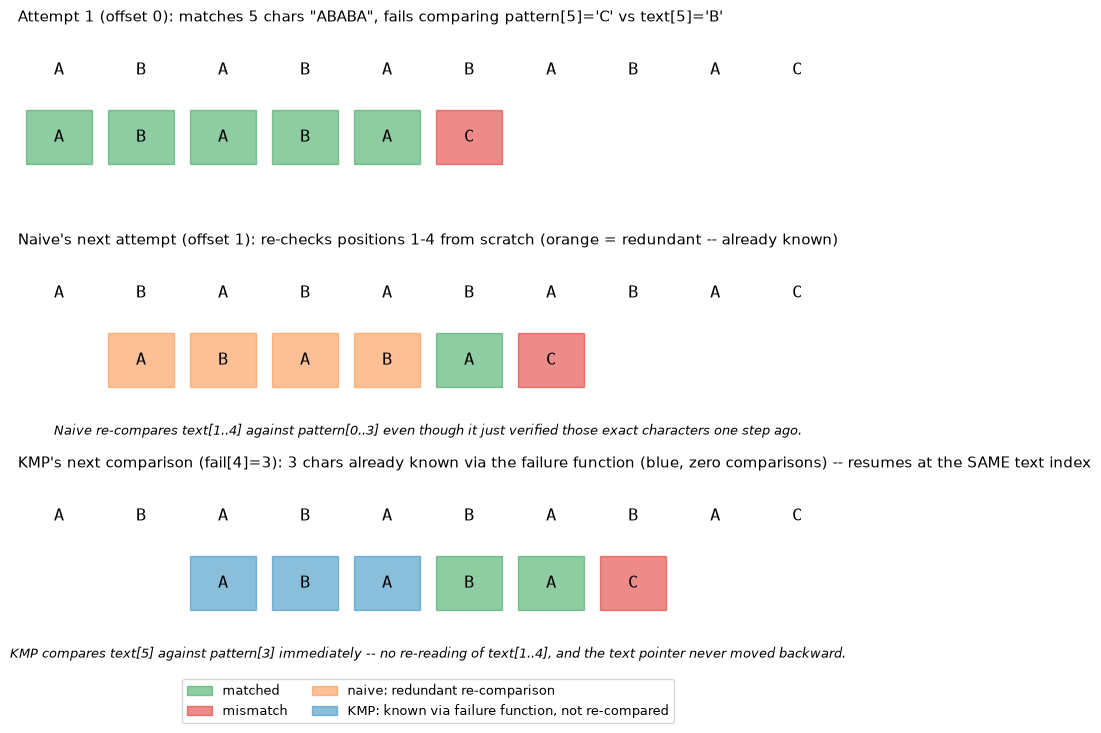

In [3]:
import matplotlib.pyplot as plt
import numpy as np

text = "ABABABABAC"
pattern = "ABABAC"
fail = build_failure_function(pattern)

# Colors: matched (green), mismatched attempt (red), redundant re-comparison
# naive would perform (orange), characters KMP already knows via the
# failure function and does NOT re-compare (blue).
COL_MATCH = "#31a354"
COL_MISMATCH = "#de2d26"
COL_REDUNDANT = "#fd8d3c"
COL_SKIPPED_KNOWN = "#2b8cbe"
COL_UNSEEN = "#f0f0f0"

def draw_alignment(ax, text, pattern, offset, char_colors, title, note=None):
    ax.set_xlim(-0.5, len(text) - 0.5)
    ax.set_ylim(-1.2, 1.6)
    ax.axis("off")
    ax.set_title(title, fontsize=11, loc="left")
    for idx, ch in enumerate(text):
        ax.text(idx, 1, ch, ha="center", va="center", fontsize=12, family="monospace")
    for pidx, ch in enumerate(pattern):
        tidx = offset + pidx
        color = char_colors[pidx] if pidx < len(char_colors) else COL_UNSEEN
        ax.add_patch(plt.Rectangle((tidx - 0.4, -0.4), 0.8, 0.8, color=color, alpha=0.55, zorder=0))
        ax.text(tidx, 0, ch, ha="center", va="center", fontsize=12, family="monospace", zorder=1)
    if note:
        ax.text(len(text) / 2 - 0.5, -1.05, note, ha="center", va="center", fontsize=9.5, style="italic")

fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.2))

# Attempt 1: aligned at offset 0. Matches "ABABA" (5 chars), fails on the 6th (pattern[5]='C' vs text[5]='B').
attempt1_colors = [COL_MATCH] * 5 + [COL_MISMATCH]
draw_alignment(axes[0], text, pattern, 0, attempt1_colors,
               "Attempt 1 (offset 0): matches 5 chars \"ABABA\", fails comparing pattern[5]='C' vs text[5]='B'")

# What NAIVE does next: slide by 1 to offset 1, re-compare from scratch --
# including 4 characters that were already confirmed matches a moment ago.
naive_colors = [COL_REDUNDANT] * 4 + [COL_MATCH] + [COL_MISMATCH]
draw_alignment(axes[1], text, pattern, 1, naive_colors,
               "Naive's next attempt (offset 1): re-checks positions 1-4 from scratch (orange = redundant -- already known)",
               note="Naive re-compares text[1..4] against pattern[0..3] even though it just verified those exact characters one step ago.")

# What KMP does: uses fail[4] = 3, so the pattern effectively realigns at
# offset 2, with the first 3 characters already known to match (blue) --
# it resumes comparing at the SAME text index (5) against pattern[3], never
# stepping the text pointer backward.
kmp_colors = [COL_SKIPPED_KNOWN] * 3 + [COL_MATCH] * 2 + [COL_MISMATCH] + [COL_MATCH]
draw_alignment(axes[2], text, pattern, 2, kmp_colors,
               "KMP's next comparison (fail[4]=3): 3 chars already known via the failure function (blue, zero comparisons) -- resumes at the SAME text index",
               note="KMP compares text[5] against pattern[3] immediately -- no re-reading of text[1..4], and the text pointer never moved backward.")

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COL_MATCH, alpha=0.55, label="matched"),
    plt.Rectangle((0, 0), 1, 1, color=COL_MISMATCH, alpha=0.55, label="mismatch"),
    plt.Rectangle((0, 0), 1, 1, color=COL_REDUNDANT, alpha=0.55, label="naive: redundant re-comparison"),
    plt.Rectangle((0, 0), 1, 1, color=COL_SKIPPED_KNOWN, alpha=0.55, label="KMP: known via failure function, not re-compared"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("kmp_step_visualization.png", dpi=110, bbox_inches="tight")
plt.show()

**The middle and bottom panels are the same moment in the search,
compared two ways.** Naive search (middle) throws away everything it
learned and re-checks four characters it had already confirmed one step
earlier. KMP (bottom) uses the failure function to know, with zero
comparisons, that those same characters still match at the new alignment
-- it only spends a comparison on genuinely new information, and the text
pointer never steps backward to re-read anything.

## Implementation

The reference implementation lives in
[`src/kmp.cpp`](src/kmp.cpp) -- real C++, implementing **both** the naive
search and KMP (failure function + linear search) side by side, each
instrumented to count character comparisons and time itself. It reads the
text and pattern (one per line) from stdin and prints match positions for
both methods, their comparison counts, and their timings.

We compile it here with `g++` and run the resulting binary via
`subprocess` -- every number below is a real measurement from a real
compiled program, not a simulation.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [4]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "kmp.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "kmp.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\kmp.exe


In [5]:
def run_kmp(text, pattern):
    # Run the real compiled kmp binary on a (text, pattern) pair, return parsed stats.
    input_str = text + "\n" + pattern + "\n"
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    stats = {}
    for line in proc.stdout.splitlines():
        if line.startswith("naive_matches:"):
            rest = line[len("naive_matches:"):].strip()
            stats["naive_matches"] = [int(x) for x in rest.split()] if rest else []
        elif line.startswith("kmp_matches:"):
            rest = line[len("kmp_matches:"):].strip()
            stats["kmp_matches"] = [int(x) for x in rest.split()] if rest else []
        elif "=" in line:
            key, val = line.split("=")
            stats[key] = int(val)
    return stats

demo_text = "ABABABABCABABABABCABABABABC"
demo_pattern = "ABABC"
stats = run_kmp(demo_text, demo_pattern)

print(f"text:    {demo_text}")
print(f"pattern: {demo_pattern}\n")
print(f"naive matches:      {stats['naive_matches']}")
print(f"kmp matches:        {stats['kmp_matches']}")
print(f"naive comparisons:  {stats['naive_comparisons']}")
print(f"kmp comparisons:    {stats['kmp_comparisons']}  (failure fn: {stats['kmp_failure_comparisons']}, search: {stats['kmp_search_comparisons']})")
print(f"naive time:         {stats['naive_microseconds']} microseconds")
print(f"kmp time:           {stats['kmp_microseconds']} microseconds")

assert stats["match"] == 1
assert stats["naive_matches"] == stats["kmp_matches"]
print("\ncorrectness check passed: naive and KMP found identical match positions")

text:    ABABABABCABABABABCABABABABC
pattern: ABABC

naive matches:      [4, 13, 22]
kmp matches:        [4, 13, 22]
naive comparisons:  63
kmp comparisons:    38  (failure fn: 5, search: 33)
naive time:         5 microseconds
kmp time:           2 microseconds

correctness check passed: naive and KMP found identical match positions


### Real benchmark: comparisons vs. text length, typical vs. adversarial input

Now let's actually measure the theory with the compiled binary. We test
two kinds of input at growing text lengths $n$, with a fixed-length
pattern:

- **Typical text**: a pseudo-random string over a small alphabet (some
  partial matches happen naturally, like ordinary text), searched for a
  pattern that appears a handful of times.
- **Adversarial text**: the worst case from the intro -- text is
  `"AAAA...A"` and the pattern is `"AAAA...AAB"`, which forces naive
  search to nearly match the whole pattern at every single position
  before failing.

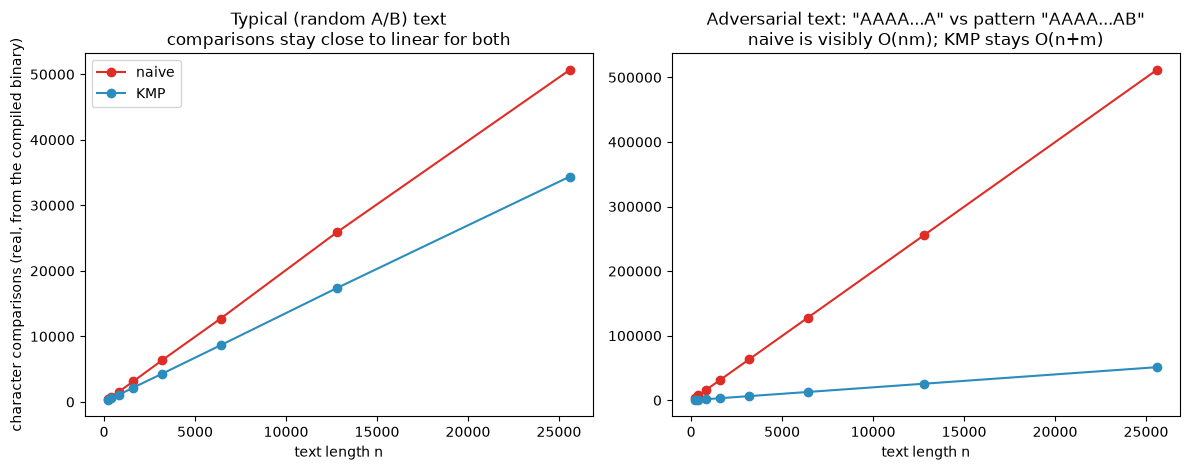

      n | typical naive   typical KMP |  adversarial naive  adversarial KMP
    200 |           399           295 |               3620              418
    400 |           756           554 |               7620              818
    800 |          1540          1081 |              15620             1618
   1600 |          3126          2177 |              31620             3218
   3200 |          6383          4316 |              63620             6418
   6400 |         12708          8642 |             127620            12818
  12800 |         25895         17382 |             255620            25618
  25600 |         50676         34391 |             511620            51218


In [6]:
import random
random.seed(42)

sizes = [200, 400, 800, 1600, 3200, 6400, 12800, 25600]
pattern_len = 20

typical_naive, typical_kmp = [], []
adversarial_naive, adversarial_kmp = [], []

typical_pattern = "".join(random.choice("AB") for _ in range(pattern_len))
adversarial_pattern = "A" * (pattern_len - 1) + "B"

for n in sizes:
    typical_text = "".join(random.choice("AB") for _ in range(n))
    t_stats = run_kmp(typical_text, typical_pattern)
    typical_naive.append(t_stats["naive_comparisons"])
    typical_kmp.append(t_stats["kmp_comparisons"])

    adversarial_text = "A" * n
    a_stats = run_kmp(adversarial_text, adversarial_pattern)
    adversarial_naive.append(a_stats["naive_comparisons"])
    adversarial_kmp.append(a_stats["kmp_comparisons"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(sizes, typical_naive, "o-", label="naive", color="#de2d26")
axes[0].plot(sizes, typical_kmp, "o-", label="KMP", color="#2b8cbe")
axes[0].set_title("Typical (random A/B) text\ncomparisons stay close to linear for both")
axes[0].set_xlabel("text length n")
axes[0].set_ylabel("character comparisons (real, from the compiled binary)")
axes[0].legend()

axes[1].plot(sizes, adversarial_naive, "o-", label="naive", color="#de2d26")
axes[1].plot(sizes, adversarial_kmp, "o-", label="KMP", color="#2b8cbe")
axes[1].set_title("Adversarial text: \"AAAA...A\" vs pattern \"AAAA...AB\"\nnaive is visibly O(nm); KMP stays O(n+m)")
axes[1].set_xlabel("text length n")

plt.tight_layout()
plt.savefig("comparisons_vs_n.png", dpi=110)
plt.show()

print(f"{'n':>7} | {'typical naive':>13} {'typical KMP':>13} | {'adversarial naive':>18} {'adversarial KMP':>16}")
for n, tn, tk, an, ak in zip(sizes, typical_naive, typical_kmp, adversarial_naive, adversarial_kmp):
    print(f"{n:7d} | {tn:13d} {tk:13d} | {an:18d} {ak:16d}")

**On typical text, naive and KMP are close** -- most mismatches
happen after 0 or 1 characters, so naive rarely pays its worst-case
penalty in practice. **On adversarial text, the gap is exactly what the
$O(nm)$ vs $O(n+m)$ analysis predicts**: naive's comparison count grows
roughly proportional to $n \times m$ (visibly curving upward), while
KMP's stays close to a straight line in $n$. This is the real payoff of
KMP's guarantee -- it's not that it's always dramatically faster, it's
that it can *never* be caught out the way naive search can.

## Use cases

- **Text editors' "find" feature.** Ctrl+F-style search on large documents
  benefits from a search that can't degrade badly on pathological input
  (e.g. a document full of repeated characters), which is exactly what
  motivated the intro's hook.
- **Bioinformatics: DNA/protein subsequence search.** Searching for a
  known short motif (e.g. a transcription factor binding site or a
  restriction enzyme recognition sequence) within a much longer genome
  sequence is a direct exact-string-matching problem, and genomic
  alphabets are small (4 or 20 symbols), which tends to produce exactly
  the kind of repetitive, partial-match-prone input where KMP's guarantee
  matters.
- **Network intrusion detection systems (NIDS).** Systems like Snort
  historically used variants of exact string-matching algorithms
  (including Aho-Corasick, KMP's multi-pattern generalization) to scan
  packet payloads for known attack signature strings, where an attacker
  who can craft payload content has a direct incentive to try to trigger
  worst-case scanning behavior -- a setting where a *guaranteed* linear
  bound is a real security property, not just a nice-to-have.
- **`grep`-like command-line search tools**, as one algorithm among
  several in the string-matching toolbox used to implement literal
  (non-regex) substring search efficiently.

## Limitations & debates

- **KMP's guarantee is worst-case, not typical-case speed.** As the
  benchmark above shows, on ordinary (non-adversarial) text, naive search
  is often nearly as fast as KMP, because most mismatches happen almost
  immediately. KMP's real advantage is a **guaranteed** $O(n+m)$ bound
  that never degrades, not that it's dramatically faster on average.
- **Boyer-Moore is the real-world default in many `grep`/text-editor
  implementations for typical text**, and it's often *faster in
  practice* than KMP despite lacking KMP's clean worst-case guarantee.
  Boyer-Moore scans the pattern against the text **right to left** and
  uses a "bad character" heuristic (and a related "good suffix" rule): on
  a mismatch, it can often skip *multiple* text characters at once instead
  of advancing one at a time, because a mismatched character tells you
  where that character would need to appear in the pattern for a match to
  be possible at all. For typical text and moderately long patterns, this
  usually beats KMP's guaranteed-but-conservative one-comparison-at-a-time
  advance. The tradeoff is genuinely contested: **KMP wins when
  adversarial or highly repetitive input is a real concern** (e.g.
  security-sensitive payload scanning, where an attacker chooses the
  input), while **Boyer-Moore-family algorithms tend to win on ordinary
  text** where average-case constant factors dominate.
- **KMP only finds exact matches.** It has no notion of "close enough" --
  a single character difference between pattern and text anywhere is a
  non-match. Real-world tasks like spell-checking, fuzzy search, or
  approximate DNA alignment (allowing for mutations/insertions/deletions)
  need fundamentally different algorithms, typically built on **edit
  distance** (e.g. dynamic-programming-based Levenshtein distance, or
  the Smith-Waterman/Needleman-Wunsch family used in bioinformatics for
  approximate sequence alignment). "Just use KMP" is a real limitation of
  thinking for anything beyond exact substring search.
- **Multi-pattern search needs a different (related) algorithm.**
  Searching for many patterns simultaneously (e.g. a NIDS checking a
  payload against thousands of known signatures at once) isn't efficiently
  done by running KMP once per pattern -- **Aho-Corasick**, which
  generalizes KMP's failure-function idea to a trie of multiple patterns,
  is the standard tool there.

## References

- Knuth, D.E., Morris, J.H., Pratt, V.R. *Fast Pattern Matching in
  Strings*, SIAM Journal on Computing, 6(2), 1977 (the original KMP
  paper).
- Boyer, R.S., Moore, J.S. *A Fast String Searching Algorithm*,
  Communications of the ACM, 20(10), 1977 (the practical alternative
  discussed in Limitations & debates).
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 32 (String Matching) -- the failure-function
  correctness argument and amortized analysis follow this treatment.
- `src/kmp.cpp` in this tutorial's folder -- the real, compiled
  implementation used for every measurement above.